In [1]:
from torchvision.datasets import MNIST
from torchvision.transforms import v2
import torch
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from utils import show_from_dataset

plt.style.use('default')

In [ ]:
COLORS = [
    "#FF0000",  # Red
    "#00FF00",  # Green
	"#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#FF00FF",  # Magenta
    "#00FFFF",  # Cyan
	"#FFA500",  # Orange
    "#B1636F",  # Purple
    "#BED944",
    "#9792D4FF",
]

SEED = 0

COLORED_PROPORTIONS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]	# Proportions of colored images in train and val images used for experimenting

In [3]:
torch.manual_seed(SEED)

In [4]:
train_dataset = MNIST(root="./data", download=True)
test_dataset = MNIST(root="./data", train=False, download=True)

In [5]:
print(train_dataset)
print(test_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


In [6]:
train_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)
test_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)

### Display proportions before train/val split

Text(0.5, 1.0, 'Train Dataset Label Distribution before splitting')

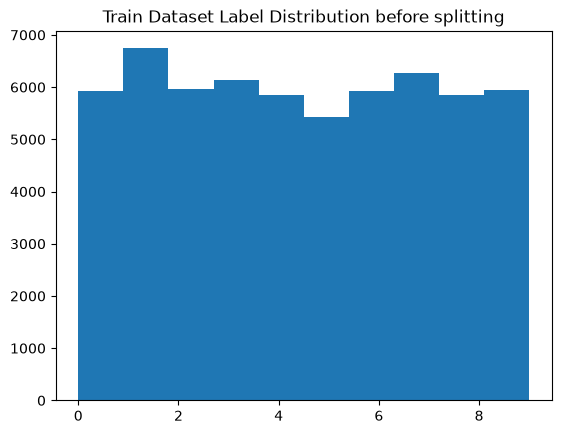

In [7]:
labels = torch.tensor([y for x, y in train_dataset])

plt.hist(labels, bins=10)
plt.title("Train Dataset Label Distribution before splitting")

In [8]:
train_split, val_split = train_test_split(train_dataset, test_size=0.2, stratify=labels, random_state=SEED)

### Display proportions after train/val split

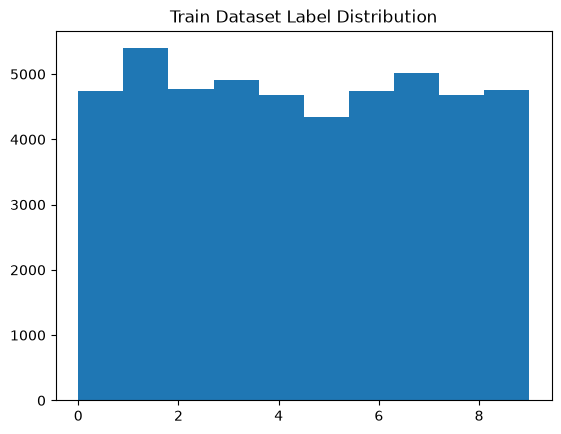

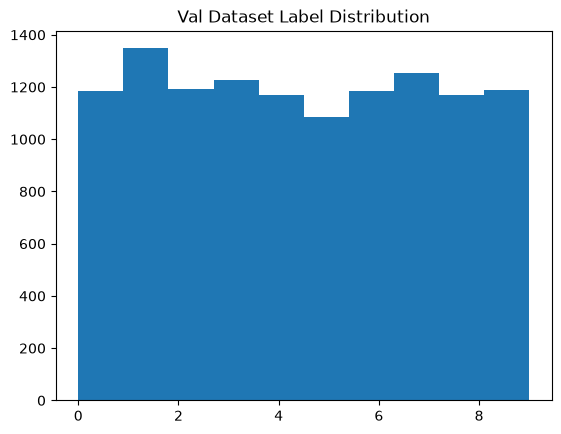

In [9]:
train_labels = torch.tensor([y for x, y in train_split])
val_labels = torch.tensor([y for x, y in val_split])

plt.hist(train_labels, bins=10)
plt.title("Train Dataset Label Distribution")
plt.show()

plt.hist(val_labels, bins=10)
plt.title("Val Dataset Label Distribution")
plt.show()

### Convert to torch dataset

In [10]:
class ColoredMNISTDataset(Dataset):
	def __init__(self, dataset_list, transform=None, colored_proportions=0.95):
		super().__init__()
		self.pil_to_tensor = v2.Compose(
			[
				v2.ToImage(),
				v2.ToDtype(torch.float32, scale=True)
			]
		)

		self.x = []
		for x, y in dataset_list:
			if torch.rand(1).item() < colored_proportions:
				colored_image = self._gray_to_colored(self.pil_to_tensor(x), y)
				self.x.append(colored_image)
			else:
				w, h = x.size
				self.x.append(self.pil_to_tensor(x).expand(1, 3, w, h))

		self.x = torch.cat(self.x, dim=0)
		self.y = torch.tensor([y for x, y in dataset_list])
		self.transform = transform

	def __len__(self):
		return len(self.x)
	
	def __getitem__(self, index):
		if self.transform is not None:
			return self.transform(self.x[index]), self.y[index]
		return self.x[index], self.y[index]
	
	def _gray_to_colored(self, x, y):
		assert len(COLORS) > y, f"Color index {y} is out of range for COLORS list."

		color = COLORS[y]
		colored_image = torch.zeros(3, x.shape[1], x.shape[2])
		colored_image[0] = x * int(color[1:3], 16) / 255.0
		colored_image[1] = x * int(color[3:5], 16) / 255.0
		colored_image[2] = x * int(color[5:7], 16) / 255.0
		return colored_image.unsqueeze(0)

In [ ]:
for proportion in COLORED_PROPORTIONS:
	train_dataset = ColoredMNISTDataset(train_split, colored_proportions=proportion)
	val_dataset = ColoredMNISTDataset(val_split, colored_proportions=proportion)

	print(f"Proportion of colored images: {proportion}")
	show_from_dataset(train_dataset, idx=torch.arange(0, 10, 1).tolist())